In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [11]:
DATA_DIR = '../../Data/splitting_data/used'
splitting_file = os.path.join(DATA_DIR, 'ACl_FILTERED_DATA_04.csv')

In [12]:
splitting_data = pd.read_csv(splitting_file)

/tmp/ipykernel_2083567/3684393674.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_2083567/3684393674.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


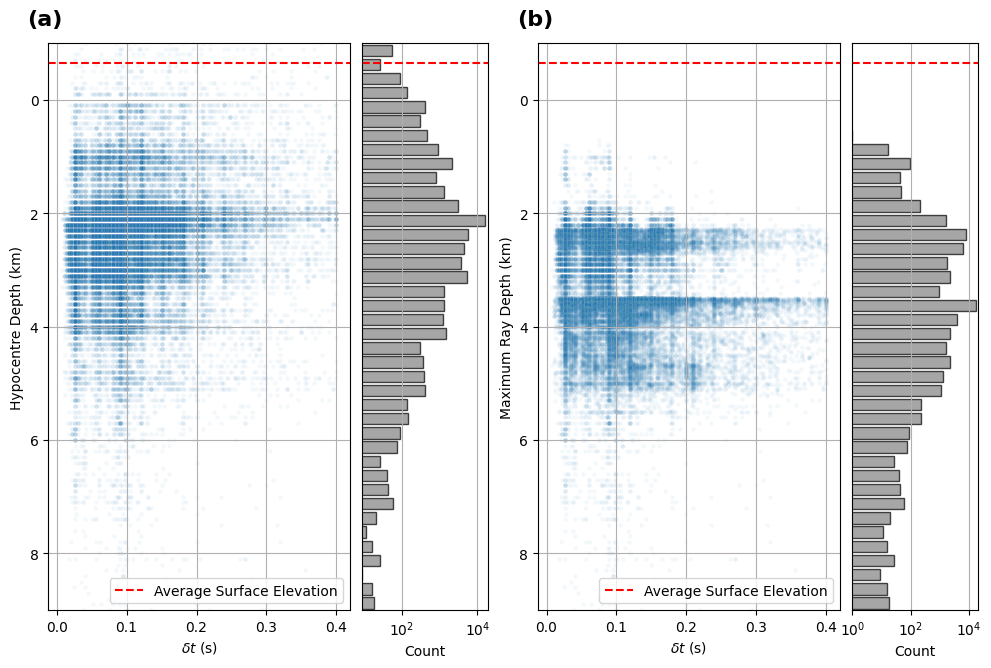

In [13]:
import numpy as np
from matplotlib import gridspec

DEPTH_MIN, DEPTH_MAX = -1, 9
AVG_SURFACE_ELEV = -0.65

# Bin edges and centers for horizontal histograms
depth_bins = np.arange(DEPTH_MIN, DEPTH_MAX + 0.25, 0.25)
if not np.isclose(depth_bins[-1], DEPTH_MAX):
    depth_bins = np.append(depth_bins, DEPTH_MAX)
bin_centers = (depth_bins[:-1] + depth_bins[1:]) / 2

fig = plt.figure(figsize=(10, 7))
gs = gridspec.GridSpec(1, 5, width_ratios=[1.2, 0.5, 0.1, 1.2, 0.5], wspace=0.07)


def plot_scatter_panel(ax, y_col, ylabel, panel_label):
    sns.scatterplot(
        data=splitting_data,
        x='tlag',
        y=y_col,
        alpha=0.05,
        s=10,
        palette='viridis',
        legend='brief',
        ax=ax,
    )
    ax.set_xlabel(r'$\delta t$ (s)')
    ax.set_ylabel(ylabel)
    ax.set_ylim(DEPTH_MIN, DEPTH_MAX)
    ax.axhline(AVG_SURFACE_ELEV, color='red', linestyle='--', label='Average Surface Elevation')
    ax.text(-0.07, 1.06, panel_label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
    ax.invert_yaxis()
    ax.grid(True)
    ax.legend(loc='lower right')
    ax.tick_params(axis='y', which='both', left=True, labelleft=True)


def plot_hist_panel(ax, values):
    counts, _ = np.histogram(values, bins=depth_bins)
    counts_plot = np.where(counts > 0, counts, np.nan)

    ax.barh(bin_centers, counts_plot, height=0.20, color='gray', edgecolor='k', alpha=0.7)
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    ax.set_ylim(DEPTH_MIN, DEPTH_MAX)
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.axhline(AVG_SURFACE_ELEV, color='red', linestyle='--')
    ax.grid(True, axis='x', which='both')
    ax.tick_params(axis='y', which='both', left=False, labelleft=False)

    nonzero_counts = counts[counts > 0]
    if nonzero_counts.size > 0:
        ax.set_xlim(left=max(1, np.min(nonzero_counts)), right=np.max(nonzero_counts) * 1.2)
    else:
        ax.set_xlim(left=1, right=10)


ax0 = plt.subplot(gs[0])
plot_scatter_panel(ax0, 'depthkm', 'Hypocentre Depth (km)', '(a)')

ax1 = plt.subplot(gs[1], sharey=ax0)
plot_hist_panel(ax1, splitting_data['depthkm'])

# gs[2] is a visual spacer

ax2 = plt.subplot(gs[3])
plot_scatter_panel(ax2, 'max_ray_depth_km', 'Maximum Ray Depth (km)', '(b)')

ax3 = plt.subplot(gs[4], sharey=ax2)
plot_hist_panel(ax3, splitting_data['max_ray_depth_km'])

fig.subplots_adjust(left=0.06, right=0.99, top=0.93, bottom=0.12, wspace=0.07)
plt.savefig('Figure_6.png', dpi=150, bbox_inches='tight', pad_inches=0.03)
